# Baseline models
#### Previous notebook: [Data provisioning](02_data_provisioning.ipynb)

#### Models implemented in this notebook:
 - [Logistic Regression](#logistic-regression)
 - [Linear SVC](#linear-svc)
 - [Multinomial Naive Bayes](#multinomial-naive-bayes)

## Load train/val/test sets
In this step, I will load the files from the split_data folder to ensure that every model is trained, tuned and evaluated on exactly the same input texts and labels. To load the data, I will use the "load_split_data" function from the `helper.py` file:

In [37]:
from utilities import helper

X_train, X_val, X_test, y_train, y_val, y_test = helper.load_split_data(show = True)
labels = list(y_train.columns)

X_train: (12122,)
X_val: (3742,)
X_test: (3742,)
y_train: (12122, 5)
y_val: (3742, 5)
y_test: (3742, 5)


## Remove non-label samples
In this step, I will filter out the non-label samples from all splits. These messages do not provide any learning signal to the models and can bias the results, because they dominate the dataset. By keeping only samples with at least one positive target, the model can focus on better distinguishing the 5 target variables:

In [38]:
import pandas as pd

def drop_no_label(X, y, labels):
    mask_keep = (y[labels].sum(axis=1) > 0)
    return X.loc[mask_keep].reset_index(drop=True), y.loc[mask_keep].reset_index(drop=True)

X_train, y_train = drop_no_label(X_train, y_train, labels)
X_val,   y_val   = drop_no_label(X_val,   y_val,   labels)
X_test,  y_test  = drop_no_label(X_test,  y_test,  labels)

## Text normalization
In this step, I will apply the text normalization explained in the data provisioning notebook. This is an important step that ensures the input consistency and noise reduction. I will do this in a separate step, instead of using it directly in the pipeline, to make model fine-tuning more efficient:

In [39]:
from utilities.text_normalization import preprocess_text

X_train_norm = X_train.map(preprocess_text)
X_val_norm   = X_val.map(preprocess_text)
X_test_norm  = X_test.map(preprocess_text)

## Building dictionaries
In this step, I construct label-specific dictionaries using the training set and selecting the top 60 chi-square terms. These dictionaries capture words that are most associated with each target variable and are used to improve the lexical signal in the dataset:

In [40]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2

def build_dicts_chi2(X_train_text, y_train, labels, top_k=60, min_df=2):
    vec = CountVectorizer(min_df=min_df,stop_words="english",binary=True)
    X_counts = vec.fit_transform(X_train_text)
    vocab = np.array(vec.get_feature_names_out())

    label_dicts = {}
    for j, lab in enumerate(labels):
        yj = y_train[lab].astype(int).to_numpy()
        scores, _ = chi2(X_counts, yj)
        top_idx = np.argsort(scores)[::-1][:top_k]
        label_dicts[lab] = set(vocab[top_idx])

    return label_dicts

dicts= build_dicts_chi2(X_train_norm, y_train, labels,top_k=60,min_df=2)
for lab in labels:
    print(lab, ":", sorted(list(dicts[lab]))[:25])

need_basic_supplies : ['agricultural', 'baby', 'bag', 'blanket', 'carrefour', 'cereal', 'clean', 'clothe', 'clothing', 'cook', 'crop', 'dead', 'death', 'distribute', 'distribution', 'donate', 'drink', 'drinking', 'drought', 'dry', 'earthquake', 'eat', 'feed', 'food', 'force']
need_medical_help : ['antibiotic', 'baby', 'basic', 'blanket', 'blood', 'care', 'case', 'cholera', 'clinic', 'dengue', 'diarrhea', 'diarrhoea', 'disease', 'doctor', 'drug', 'ebola', 'emergency', 'epidemic', 'facility', 'fever', 'health', 'hospital', 'hygiene', 'illness', 'include']
need_safety_rescue : ['al', 'armed', 'army', 'attack', 'boko', 'bomb', 'bombing', 'civilian', 'clash', 'commit', 'conflict', 'coup', 'crime', 'effort', 'ethnic', 'fight', 'fighter', 'fighting', 'food', 'force', 'government', 'group', 'haram', 'helicopter', 'islamist']
need_shelter : ['bed', 'blanket', 'build', 'camp', 'construct', 'cooking', 'corrugated', 'damage', 'death', 'destroy', 'disease', 'family', 'floor', 'generator', 'help', '

### Manually cleaning
After constructing the initial 5 dictionaries, I manually reviewed the selected terms for each category and removed generic and noisy words. The goal is to keep a compact set of domain-relevant keywords that are strongly indicative of each target class:

In [41]:
for w in sorted(dicts["need_basic_supplies"]):
    print(w)

agricultural
baby
bag
blanket
carrefour
cereal
clean
clothe
clothing
cook
crop
dead
death
distribute
distribution
donate
drink
drinking
drought
dry
earthquake
eat
feed
food
force
good
help
hospital
hunger
hungry
hygiene
item
kill
latrine
let
meal
medicine
need
non
oil
perishable
product
provide
purification
purify
ration
rebel
rescue
rice
sanitation
say
shortage
source
starve
supply
tablet
thank
ton
water
wfp


In [42]:
remove = { "carrefour", "dead","death","distribute","distribution","donate","force","good","help","hospital","item","kill","let","medicine","need","non","product","provide","rebel","rescue","say","source","supply","thank","ton","wfp"}
dicts["need_basic_supplies"] = {
    w for w in dicts["need_basic_supplies"]
    if w not in remove
}

for w in sorted(dicts["need_medical_help"]):
    print(w)

antibiotic
baby
basic
blanket
blood
care
case
cholera
clinic
dengue
diarrhea
diarrhoea
disease
doctor
drug
ebola
emergency
epidemic
facility
fever
health
hospital
hygiene
illness
include
infection
influenza
item
kit
malaria
measle
medical
medication
medicine
mosquito
net
oral
outbreak
patient
pneumonia
prevent
product
provide
respiratory
risk
sanitation
sick
skin
soap
supply
support
symptom
team
toilet
treat
treatment
unicef
vaccination
vaccine
virus


In [43]:
remove = {"basic","blanket","case","include","item", "kit","product","provide","support","team","supply","sanitation","soap","toilet","unicef","risk"}
dicts["need_medical_help"] = {
    w for w in dicts["need_medical_help"]
    if w not in remove
}

for w in sorted(dicts["need_safety_rescue"]):
    print(w)

al
armed
army
attack
boko
bomb
bombing
civilian
clash
commit
conflict
coup
crime
effort
ethnic
fight
fighter
fighting
food
force
government
group
haram
helicopter
islamist
kenyan
mali
malian
militant
military
militia
need
operation
party
personnel
police
political
raid
rebel
rescue
rubble
rule
search
security
shoot
soldier
somalia
suicide
taliban
target
tent
terrorist
trap
troop
tuareg
violence
violent
war
water
worker


In [44]:
remove = { "al","commit","effort","food","government","group","need","operation","party","personnel","political","rule","search","target","tent","water","worker","kenyan","mali","malian","somalia","tuareg"}
dicts["need_safety_rescue"] = {
    w for w in dicts["need_safety_rescue"]
    if w not in remove
}

for w in sorted(dicts["need_shelter"]):
    print(w)

bed
blanket
build
camp
construct
cooking
corrugated
damage
death
destroy
disease
family
floor
generator
help
home
homeless
house
housing
iom
item
jerry
kit
kitchen
live
makeshift
mat
material
mattress
need
open
outside
permanent
place
plastic
provide
rain
refuge
roof
room
school
set
sheet
sheeting
shelter
sleep
soak
stay
stove
street
tarp
tarpaulin
temporary
tent
thank
utensil
village
warm
winter
winterize


In [45]:
remove = {"build","construct","cooking","damage","death","disease","generator","help","iom","item","kit","kitchen","live","material","need","open","place","provide","school","set","stay","stove","thank","utensil","village"}
dicts["need_shelter"] = {
    w for w in dicts["need_shelter"]
    if w not in remove
}

for w in sorted(dicts["people_status"]):
    print(w)

000
11
afp
body
bury
camp
claim
dead
death
die
displace
displacement
drown
earthquake
eastern
evacuate
evacuation
fear
flee
flood
food
heavy
hit
home
injure
june
kill
landslide
leave
life
ly
magnitude
massive
million
miss
monday
monsoon
mudslide
nearly
need
official
past
people
powerful
quake
refugee
region
report
return
river
say
state
storm
strike
thousand
toll
trigger
water
wind
xinhua


In [46]:
remove = {"000","11","afp","claim","food","heavy","hit","home","june","leave","life","ly","magnitude","massive","million","monday","nearly","need","official","past","people","powerful",
"region","report","river","say","state","thousand","water","wind","xinhua"}
dicts["people_status"] = {
    w for w in dicts["people_status"]
    if w not in remove
}

## Save final dictionaries

In [47]:
import json

dicts_clean = dicts
with open("../data/dicts_new.json", "w") as f:
    json.dump({k: sorted(list(v)) for k, v in dicts_clean.items()}, f, indent=2)

## Extract features from dictionaries
In this step, I convert the cleaned label-specific dictionaries into numerical features. I implement a transformer that maps each message to a set of dictionary-based features. For each target variable are being extracted 2 features - the number of tokens in the message that appear in the dictionary and a binary indicator to show whether any dictionary keywords appear in the specific message:

In [48]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class DictFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, label_dicts):
        self.label_dicts = label_dicts
        self.labels_ = list(label_dicts.keys())

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        feats = np.zeros((len(X), 2 * len(self.labels_)), dtype=np.float32)

        for i, text in enumerate(X):
            toks = (text or "").split()
            tok_set = set(toks)

            for j, lab in enumerate(self.labels_):
                vocab = self.label_dicts[lab]
                cnt = sum(1 for t in toks if t in vocab)
                feats[i, 2*j] = cnt
                feats[i, 2*j + 1] = 1.0 if any(t in vocab for t in tok_set) else 0.0

        return feats

## Setting TF-IDF
In this step, I create a TF-IDF vectorizer configuration function to create a new vectorizer for each model. The TF-IDF vectorizer is used to measure how important a token is - tokens that are frequent in a message but not that frequent across the whole dataset, will be assigned with higher weights. Before tokenization and weighting, the text message is normalized by the `preprocess_text` function to ensure the consistency of the input format and reduce noise - the text is lowercased; URLs, emails, user mentions, hashtags and numbers are replaced with fixed placeholder tokens; extra white spaces are removed and spaCy lemmatization is applied to reduce the words to their base or dictionary form. After that, the text is tokenized by splitting on white spaces. The *ngram_range* uses both unigrams(single words) and bigrams(pair of 2 words) to capture short phrases, which might carry important information. Lasty, *min_df* and *max_df* are used to exclude very rare and too common tokens in order to reduce noise and improve generalization.

In [62]:
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer

def make_tfidf():
    uni = TfidfVectorizer(
        preprocessor=None,
        tokenizer=str.split,
        ngram_range=(1, 1),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        token_pattern=None
    )

    bi = TfidfVectorizer(
        preprocessor=None,
        tokenizer=str.split,
        ngram_range=(2, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        token_pattern=None
    )

    return FeatureUnion([
        ("uni", uni),
        ("bi", bi),
    ])

def make_features(dicts_clean):
    return FeatureUnion([
        ("tfidf", make_tfidf()),
        ("dict", DictFeatures(dicts_clean)),
    ])

## Get model scores
Different models score their predictions in different ways - some give probabilities in the range 0-1, while others base their decisions on negative and positive scores. In this notebook I implement both types of models, which is why the function below checks which scoring method the model supports and returns the correct score matrix. These scores are later compared to a chosen threshold and converted into the final binary multi-label predictions:

In [50]:
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return scores

## Choose best threshold
In this step, I create a function to select the best threshold per label for turning the models' scores into final 0/1 predictions. The baseline models do not output direct binary labels - instead they output confidence scores. In the previous version of the notebook, I was selecting one threshold for all labels, which is not ideal as some labels are rarer than others. The function takes the real labels, the confidence scores and a list of thresholds. For each label, it tries each candidate threshold and converts the scores into 0/1 binary predictions. Then, it computes the F1 score for that label and stores the threshold with the highest F1. Finally, the function returns an array of thresholds and the best F1 for each label:

In [51]:
from sklearn.metrics import f1_score

def best_thresholds_per_label_from_scores(y_true, y_scores, thresholds):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)

    best_t = np.zeros(y_true.shape[1])
    best_f1 = np.zeros(y_true.shape[1])

    for j in range(y_true.shape[1]):
        yj = y_true[:, j]
        sj = y_scores[:, j]

        best_f1_j = -1.0
        best_t_j = thresholds[0]

        for t in thresholds:
            pred = (sj >= t).astype(int)
            f1 = f1_score(yj, pred, zero_division=0)
            if f1 > best_f1_j:
                best_f1_j = f1
                best_t_j = t

        best_t[j] = best_t_j
        best_f1[j] = best_f1_j

    return best_t, best_f1

## General tuning
The purpose of this function is to construct a model, train it, test different hyperparameter values and, for each value, find the best decision threshold, using the previous function (*best_thresholds_per_label_from_scores*). For each *param_grid* setting, it finds and saves the best threshold and micro F1-score. In the end, the function returns the parameter setting that achieved the highest micro F1-score, as well as a table presenting the results of all tested hyperparameters settings:

In [52]:
def general_tuning(X_train, y_train, X_val, y_val,make_pipeline_fn,param_grid,thresholds):
    rows = []

    for params in param_grid:
        model = make_pipeline_fn()
        model.set_params(**params)
        model.fit(X_train, y_train)

        y_scores = get_scores(model, X_val)
        best_t, best_f1_per_label = best_thresholds_per_label_from_scores(y_val, y_scores, thresholds)
        y_pred = (y_scores >= best_t.reshape(1, -1)).astype(int)
        val_micro = f1_score(y_val, y_pred, average="micro", zero_division=0)

        rows.append({
            **params,
            "val_micro_f1": float(val_micro),
            "thresholds_per_label": best_t.tolist(),
            "val_f1_per_label": best_f1_per_label.tolist(),
            "model": model
        })

    best = max(rows, key=lambda r: r["val_micro_f1"])
    return best, pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in rows])

## Evaluation
The purpose of the *evalute_model* function is to evaluate an already trained model. First, it gets the model's confidence scores and uses the selected threshold to convert them into binary predictions. After that it calculates the model's micro and macro F1-score, the Hamming loss and the micro Jaccard score, and saves them along with the model's name and threshold. Finally, it returns the results with the predicted labels:

In [53]:
from sklearn.metrics import hamming_loss, jaccard_score

def evaluate_model(model, X, y, thresholds_per_label, model_name):
    y_scores = get_scores(model, X)
    thr = np.asarray(thresholds_per_label, dtype=float)
    y_pred = (y_scores >= thr.reshape(1, -1)).astype(int)

    metrics_row = {
        "model": model_name,
        "thresholds_per_label": thr.tolist(),
        "micro_f1": float(f1_score(y, y_pred, average="micro", zero_division=0)),
        "macro_f1": float(f1_score(y, y_pred, average="macro", zero_division=0)),
        "hamming_loss": float(hamming_loss(y, y_pred)),
        "jaccard_micro": float(jaccard_score(y, y_pred, average="micro", zero_division=0)),
    }

    return metrics_row, y_pred

The evaluation metrics used in this project are specifically chosen for proper multi-label classification evaluation:
 - **Micro F1-score** - shows the overall performance of a model across all labels; works well with imbalanced dataset; could hide poor performance on rare labels
 - **Macro F1-score** - calculates the F1-score for all labels and averages the results, gives equal importance to each label, useful to show how a model performs on rare labels
 - **Hamming loss** - shows the fraction of incorrectly predicted labels, lower results show better performance
 - **Jaccard similarity** - measures the overlap between true and predicted labels, strict - predicting extra labels or missing true labels reduces the score, higher results show better performance

# Modeling
## Logistic Regression
In this step, I will create a function that returns a new unfitted model on each run, which makes hyperparameter tuning easier. First, I create a pipeline to ensure no data leakage is introduced. The first step in the pipeline is the TF-IDF vectorizer, which converts each input message into numerical features and ensures text normalization and consistency. Then, the model is wrapped into "OneVsRestClassifier", which is very important for multi-label classification problems - creates and trains separate Logistic Regression per label and combines the outputs for the final prediction. The hyperparameter C is used to control th regularization of the model - smaller values apply stronger regularization, bigger values allow the model to fit more closely on the data. The *class_weight* is set to balanced to help the model handle label imbalance - gives more weight to the minority class during training.

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline

def make_lr_pipe():
    return Pipeline([
    ("feats", make_features(dicts_clean)),
    ("clf", OneVsRestClassifier(LogisticRegression(max_iter=2000, class_weight="balanced")))
])

### Tuning model
In this step, I will use the *general_tuning* function to tune the Logistic Regression and find the threshold that gives the highest micro F1-score on the validation set. The *C_grid* list consists of smaller and larger numbers close to the default value to test different regularization strengths.

In [55]:
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterGrid

param_grid = list(ParameterGrid({
     "clf__estimator__C": [0.5, 1.0, 2.0],
    "feats__tfidf__uni__min_df": [1, 2],
    "feats__tfidf__uni__max_df": [0.9, 0.95],
    "feats__tfidf__uni__sublinear_tf": [True, False],
    "feats__tfidf__bi__min_df": [1, 2],
    "feats__tfidf__bi__max_df": [0.9, 0.95],
    "feats__tfidf__bi__sublinear_tf": [True, False]
}))
thresholds = np.arange(0.2, 0.81, 0.05)
best_lr, lr_results = general_tuning(X_train_norm, y_train, X_val_norm, y_val,make_pipeline_fn=make_lr_pipe,param_grid=param_grid,thresholds=thresholds)

print("Best LR params:", {k: best_lr[k] for k in best_lr if k not in ["model"]})
display(lr_results.sort_values("val_micro_f1", ascending=False).head(10))

Best LR params: {'clf__estimator__C': 2.0, 'feats__tfidf__bi__max_df': 0.9, 'feats__tfidf__bi__min_df': 1, 'feats__tfidf__bi__sublinear_tf': False, 'feats__tfidf__uni__max_df': 0.9, 'feats__tfidf__uni__min_df': 2, 'feats__tfidf__uni__sublinear_tf': True, 'val_micro_f1': 0.7659115426105717, 'thresholds_per_label': [0.5999999999999999, 0.44999999999999996, 0.49999999999999994, 0.6499999999999999, 0.44999999999999996], 'val_f1_per_label': [0.9162833486660533, 0.7132701421800948, 0.6522593320235757, 0.7891373801916933, 0.6479750778816199]}


,clf__estimator__C,feats__tfidf__bi__max_df,feats__tfidf__bi__min_df,feats__tfidf__bi__sublinear_tf,feats__tfidf__uni__max_df,feats__tfidf__uni__min_df,feats__tfidf__uni__sublinear_tf,val_micro_f1,thresholds_per_label,val_f1_per_label
142,2.0,0.90,1,False,0.95,2,True,0.765912,"[0.5999999999999999, 0.44999999999999996, 0.49...","[0.9162833486660533, 0.7132701421800948, 0.652..."
138,2.0,0.90,1,False,0.90,2,True,0.765912,"[0.5999999999999999, 0.44999999999999996, 0.49...","[0.9162833486660533, 0.7132701421800948, 0.652..."
170,2.0,0.95,1,False,0.90,2,True,0.765912,"[0.5999999999999999, 0.44999999999999996, 0.49...","[0.9162833486660533, 0.7132701421800948, 0.652..."
174,2.0,0.95,1,False,0.95,2,True,0.765912,"[0.5999999999999999, 0.44999999999999996, 0.49...","[0.9162833486660533, 0.7132701421800948, 0.652..."
166,2.0,0.95,1,True,0.95,2,True,0.765419,"[0.5999999999999999, 0.44999999999999996, 0.49...","[0.9162833486660533, 0.7132701421800948, 0.650..."
162,2.0,0.95,1,True,0.90,2,True,0.765419,"[0.5999999999999999, 0.44999999999999996, 0.49...","[0.9162833486660533, 0.7132701421800948, 0.650..."
130,2.0,0.90,1,True,0.90,2,True,0.765419,"[0.5999999999999999, 0.44999999999999996, 0.49...","[0.9162833486660533, 0.7132701421800948, 0.650..."
134,2.0,0.90,1,True,0.95,2,True,0.765419,"[0.5999999999999999, 0.44999999999999996, 0.49...","[0.9162833486660533, 0.7132701421800948, 0.650..."
137,2.0,0.90,1,False,0.90,1,False,0.765292,"[0.5999999999999999, 0.44999999999999996, 0.49...","[0.9164370982552801, 0.7095238095238096, 0.652..."
141,2.0,0.90,1,False,0.95,1,False,0.765292,"[0.5999999999999999, 0.44999999999999996, 0.49...","[0.9164370982552801, 0.7095238095238096, 0.652..."


The tuning results show that the model scored the highest micro F1-score (0.62) with regularization strength of 2.0 and threshold of nearly 0.55. This suggests that the model performs best on this multi-label classification task with slightly weaker regularization and a threshold just above the default 0.5, which helps balance precision and recall.

### Evaluation
In this step, I will evaluate the performance of the best model using the evaluate function explained in the beginning of the notebook. After that, I will print a classification report to visualise the perfomance of the model on each label separately:

In [56]:
from sklearn.metrics import classification_report
import pandas as pd

results, y_test_pred = evaluate_model( best_lr["model"], X_test_norm, y_test, best_lr["thresholds_per_label"], "Logistic Regression")
lr_df = pd.DataFrame([results])
lr_df.to_csv("../data/results/logistic_regression_results_dict_new.csv", index=False)
display(lr_df)
print("Classification report:")
print(classification_report(y_test, y_test_pred, target_names=labels, zero_division=0))

,model,thresholds_per_label,micro_f1,macro_f1,hamming_loss,jaccard_micro
0,Logistic Regression,"[0.5999999999999999, 0.44999999999999996, 0.49...",0.768987,0.743286,0.134873,0.624679


Classification report:
                     precision    recall  f1-score   support

need_basic_supplies       0.92      0.89      0.91       576
  need_medical_help       0.75      0.71      0.73       433
 need_safety_rescue       0.66      0.59      0.63       269
       need_shelter       0.84      0.77      0.80       355
      people_status       0.62      0.68      0.65       295

          micro avg       0.78      0.76      0.77      1928
          macro avg       0.76      0.73      0.74      1928
       weighted avg       0.79      0.76      0.77      1928
        samples avg       0.78      0.80      0.76      1928



The results above show that the Logistic regression model achieves micro F1-score of 0.619, macro F1 - 0.591, hamming loss of 0.076 and Jaccard = 0.448. The small difference between the micro and macro F1-scores, suggests that the model performs slightly better with more common labels rather than the rare ones. The Hamming loss result shows that most label decisions are correct - lower incorrectly predicted label fraction. The Jaccard score shows moderate prediction between the true and predicted labels, probably because the model often predicts some correct labels per message but does not always match the full set perfectly. The classification report shows that the model performance best for the "need_basic_supplies" and struggles mostly with the "need_safety_rescue" label, which is probably due to the label imbalance and the fact that some words or phrases can overlap per label, making it harder to distinguish them.

## Linear SVC
Similarly to the previous model, in this step I will create a function that returns a new unfitted Linear SVC on each run. First in the pipeline is the TF-IDF vectorizer, which is used to apply the same text preprocessing and convert the input message into numerical features. Then, the model is wrapped in "OneVsRestClassifier" to create a linear SVC for each label and then combine all predictions in one. I assign the *class_weight* again to balanced to reduce the impact of label imbalance.

In [59]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline

def make_svc_pipe():
    return Pipeline([
        ("feats", make_features(dicts_clean)),
        ("clf", OneVsRestClassifier(LinearSVC(class_weight="balanced", max_iter=2000)))
    ])

#### Tuning model
In this step, I will tune the linear SVC model similarly to the previous one. The difference here is that the model provides decision scores instead of probabilities. To create the threshold grid, I create 25 evenly placed points between the 5th and the 95th percentiles. Next, I use the *general_tuning* function to store and find the hyperparameter value and threshold that has the highest micro F1-score:

In [60]:
import numpy as np
from sklearn.model_selection import ParameterGrid
import pandas as pd

param_grid = list(ParameterGrid({
     "clf__estimator__C": [0.25, 0.5, 1.0, 2.0, 4.0],
    # "feats__tfidf__uni__min_df": [1, 2],
    # "feats__tfidf__uni__max_df": [0.9, 0.95],
    # "feats__tfidf__uni__sublinear_tf": [True, False],
    # "feats__tfidf__bi__min_df": [1, 2],
    # "feats__tfidf__bi__max_df": [0.9, 0.95],
    # "feats__tfidf__bi__sublinear_tf": [True, False]
}))

svc_probe = make_svc_pipe()
svc_probe.fit(X_train, y_train)
val_scores = get_scores(svc_probe, X_val)
q = np.linspace(1, 99, 41)
thresholds = np.unique(np.concatenate([np.percentile(val_scores[:, j], q)for j in range(val_scores.shape[1])]))
best_svc, svc_results = general_tuning(X_train_norm, y_train, X_val_norm, y_val,make_pipeline_fn=make_svc_pipe,param_grid=param_grid,thresholds=thresholds)

print("Best SVC params:", {k: best_svc[k] for k in best_svc if k not in ["model"]})
display(svc_results.sort_values("val_micro_f1", ascending=False).head(10))

C:\Users\katit\PycharmProjects\CHC\.venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\katit\PycharmProjects\CHC\.venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\katit\PycharmProjects\CHC\.venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\katit\PycharmProjects\CHC\.venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\katit\PycharmProjects\CHC\.venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\katit\PycharmProjects\CHC\.venv\Lib\site-packages\s

Best SVC params: {'clf__estimator__C': 0.25, 'val_micro_f1': 0.7674042093901781, 'thresholds_per_label': [0.06779947648405048, -0.10845461142363587, 0.06779947648405048, 0.10338791145715724, -0.073926448425652], 'val_f1_per_label': [0.9178832116788321, 0.7124260355029586, 0.6516393442622951, 0.7895545314900153, 0.645367412140575]}


,clf__estimator__C,val_micro_f1,thresholds_per_label,val_f1_per_label
0,0.25,0.767404,"[0.06779947648405048, -0.10845461142363587, 0....","[0.9178832116788321, 0.7124260355029586, 0.651..."
1,0.50,0.763022,"[0.06779947648405048, -0.13390627515246745, -0...","[0.9182736455463728, 0.7054714784633295, 0.647..."
2,1.00,0.761483,"[-0.03158601460392088, -0.005701454243191641, ...","[0.9180327868852459, 0.7029077117572693, 0.643..."
3,2.00,0.758601,"[0.08595385455166239, -0.03158601460392088, -0...","[0.9162833486660533, 0.6967418546365914, 0.644..."
4,4.00,0.755360,"[0.08595385455166239, -0.11663924461798908, 0....","[0.9154411764705882, 0.6947115384615384, 0.643..."


As we can see from above, the model score the highest micro F1-score with smaller regularization and a threshold of approximately 0.078. The results show that this model needs stronger regularization to perform better. Additionally, the threshold value looks small, just because the model does not output probabilities.

#### Evaluation
In this step, I will evaluate the performance of the best model using the evaluate function explained in the beginning of the notebook. After that, I will print a classification report to visualise the perfomance of the model on each label separately:

In [61]:
from sklearn.metrics import classification_report

results, y_test_pred = evaluate_model(best_svc["model"], X_test_norm, y_test, best_svc["thresholds_per_label"],"LinearSVC")

svm_df = pd.DataFrame([results])
svm_df.to_csv("../data/results/linear_svc_results_dict_new.csv", index=False)

display(svm_df)
print("Classification report:")
print(classification_report(y_test, y_test_pred, target_names=labels, zero_division=0))

,model,thresholds_per_label,micro_f1,macro_f1,hamming_loss,jaccard_micro
0,LinearSVC,"[0.06779947648405048, -0.10845461142363587, 0....",0.771995,0.74524,0.132871,0.628657


Classification report:
                     precision    recall  f1-score   support

need_basic_supplies       0.92      0.90      0.91       576
  need_medical_help       0.74      0.71      0.72       433
 need_safety_rescue       0.71      0.57      0.63       269
       need_shelter       0.81      0.79      0.80       355
      people_status       0.65      0.68      0.66       295

          micro avg       0.79      0.76      0.77      1928
          macro avg       0.76      0.73      0.75      1928
       weighted avg       0.79      0.76      0.77      1928
        samples avg       0.78      0.80      0.77      1928



Overall, the results above show that the model achieved micro F1 score of 0.625, macro F1-score of 0.595, Hamming loss of 0.076 and Jaccard score of 0.45. Similarly to the previous model, the Linear SVC performs better with more common labels. From the classification report, I can see that the SVC performs well with the "need_basic_supplies" and struggles with the "need_safety_rescue" label. Overall, the results show slightly better performance than the Logistic regression.

## Multinomial Naive Bayes
Multinomial Naive Bayes is a fast text classification model that presents a messages as a bag of word counts and uses the Bayes rule to determine a conditional probability of an event based on prior knowledge form the data and new evidence (the words in the message). The Bayes theorem is a mathematical formula used to outline important terms related to the concept of the target variable. The pipeline of this model stays consistent with the pipeline of the previous 2 models - first, the TF-IDF normalises the text and converts it into numerical vector of word weights, then the model is wrapped in "OneVSRestClassifier" to create multiple models per target variable:

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline

def make_mnb_pipe():
    return Pipeline([
        ("feats", make_features(dicts_clean)),
        ("clf", OneVsRestClassifier(MultinomialNB()))
    ])

#### Tuning model
In this step, I will perform general tuning of the model. First, the hyperparameters for the TF-IDF and the model are tuned. These parameters control how strongly the model reacts to rare words and whether it learns how common a target variable. Next, I use the `best_thresholds_per_label_from_scores` function to find the best thresholds per label:

In [64]:
import numpy as np
from sklearn.model_selection import ParameterGrid
import pandas as pd

param_grid_mnb = list(ParameterGrid({
    "clf__estimator__alpha": [0.1, 0.3, 0.5, 1.0, 2.0],
    "clf__estimator__fit_prior": [True, False],
    "feats__tfidf__uni__min_df": [1, 2],
    "feats__tfidf__uni__max_df": [0.9, 0.95],
    "feats__tfidf__uni__sublinear_tf": [True, False],
    "feats__tfidf__bi__min_df": [1, 2],
    "feats__tfidf__bi__max_df": [0.9, 0.95],
    "feats__tfidf__bi__sublinear_tf": [True, False]
}))

thresholds = np.arange(0.2, 0.81, 0.05)
best_mnb, mnb_results = general_tuning(X_train_norm, y_train, X_val_norm, y_val,make_pipeline_fn=make_mnb_pipe,param_grid=param_grid_mnb,thresholds=thresholds)

print("Best MNB params:", {k: best_mnb[k] for k in best_mnb if k not in ["model"]})
display(mnb_results.sort_values("val_micro_f1", ascending=False).head(10))

Best MNB params: {'clf__estimator__alpha': 0.5, 'clf__estimator__fit_prior': True, 'feats__tfidf__bi__max_df': 0.9, 'feats__tfidf__bi__min_df': 2, 'feats__tfidf__bi__sublinear_tf': True, 'feats__tfidf__uni__max_df': 0.9, 'feats__tfidf__uni__min_df': 2, 'feats__tfidf__uni__sublinear_tf': True, 'val_micro_f1': 0.7548616817310326, 'thresholds_per_label': [0.7999999999999998, 0.2, 0.49999999999999994, 0.5499999999999999, 0.44999999999999996], 'val_f1_per_label': [0.8980355472404116, 0.7185354691075515, 0.6838709677419355, 0.745398773006135, 0.6159052453468697]}


,clf__estimator__alpha,clf__estimator__fit_prior,feats__tfidf__bi__max_df,feats__tfidf__bi__min_df,feats__tfidf__bi__sublinear_tf,feats__tfidf__uni__max_df,feats__tfidf__uni__min_df,feats__tfidf__uni__sublinear_tf,val_micro_f1,thresholds_per_label,val_f1_per_label
278,0.5,True,0.90,2,True,0.95,2,True,0.754862,"[0.7999999999999998, 0.2, 0.49999999999999994,...","[0.8980355472404116, 0.7185354691075515, 0.683..."
274,0.5,True,0.90,2,True,0.90,2,True,0.754862,"[0.7999999999999998, 0.2, 0.49999999999999994,...","[0.8980355472404116, 0.7185354691075515, 0.683..."
310,0.5,True,0.95,2,True,0.95,2,True,0.754862,"[0.7999999999999998, 0.2, 0.49999999999999994,...","[0.8980355472404116, 0.7185354691075515, 0.683..."
306,0.5,True,0.95,2,True,0.90,2,True,0.754862,"[0.7999999999999998, 0.2, 0.49999999999999994,...","[0.8980355472404116, 0.7185354691075515, 0.683..."
318,0.5,True,0.95,2,False,0.95,2,True,0.754521,"[0.7999999999999998, 0.2, 0.49999999999999994,...","[0.8980355472404116, 0.7170675830469645, 0.683..."
314,0.5,True,0.95,2,False,0.90,2,True,0.754521,"[0.7999999999999998, 0.2, 0.49999999999999994,...","[0.8980355472404116, 0.7170675830469645, 0.683..."
286,0.5,True,0.90,2,False,0.95,2,True,0.754521,"[0.7999999999999998, 0.2, 0.49999999999999994,...","[0.8980355472404116, 0.7170675830469645, 0.683..."
282,0.5,True,0.90,2,False,0.90,2,True,0.754521,"[0.7999999999999998, 0.2, 0.49999999999999994,...","[0.8980355472404116, 0.7170675830469645, 0.683..."
287,0.5,True,0.90,2,False,0.95,2,False,0.753955,"[0.7999999999999998, 0.2, 0.39999999999999997,...","[0.897003745318352, 0.7170675830469645, 0.6819..."
283,0.5,True,0.90,2,False,0.90,2,False,0.753955,"[0.7999999999999998, 0.2, 0.39999999999999997,...","[0.897003745318352, 0.7170675830469645, 0.6819..."


#### Evaluation

In [65]:
from sklearn.metrics import classification_report

results, y_test_pred = evaluate_model(best_mnb["model"], X_test_norm, y_test, best_mnb["thresholds_per_label"], "Multinomial Naive Bayes")
mnb_df = pd.DataFrame([results])
mnb_df.to_csv("../data/results/mnb_results_dict_new.csv", index=False)
display(mnb_df)
print("Classification report:")
print(classification_report(y_test, y_test_pred, target_names=labels, zero_division=0))

,model,thresholds_per_label,micro_f1,macro_f1,hamming_loss,jaccard_micro
0,Multinomial Naive Bayes,"[0.7999999999999998, 0.2, 0.49999999999999994,...",0.739107,0.710205,0.149346,0.586177


Classification report:
                     precision    recall  f1-score   support

need_basic_supplies       0.91      0.85      0.88       576
  need_medical_help       0.70      0.73      0.72       433
 need_safety_rescue       0.74      0.55      0.63       269
       need_shelter       0.76      0.74      0.75       355
      people_status       0.62      0.54      0.58       295

          micro avg       0.77      0.71      0.74      1928
          macro avg       0.75      0.68      0.71      1928
       weighted avg       0.77      0.71      0.74      1928
        samples avg       0.77      0.77      0.74      1928



The model achieved a Micro f1 of 0.52, a Macro f1 of 0.48, a Hamming loss of 0.09 and Jaccard score of 0.35. Overall, the results show similar patterns with the previous 2 models, confirming that *people status* and *need_safety_rescue* are the hardest labels for the models to predict. The lower performance of the Multinomial Naive Bayes was expected because the of the way the model makes its predictions - it mostly relies on individual words and is less effective at capturing meaning that depends on phrases. Additionally, as we can see from the classification report the model performs best when the signal is dominated by few label specific keywords, while it struggles with labels such as *need_safety_rescue* which could be expressed in many different ways.

## Model Comparison

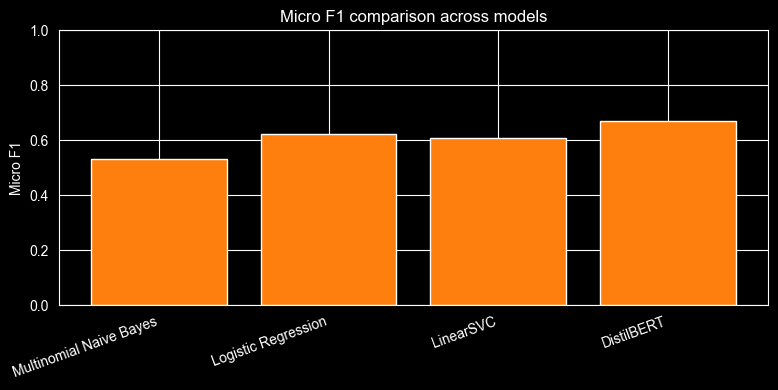

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

mnb   = pd.read_csv("../data/results/mnb_results.csv")
lr    = pd.read_csv("../data/results/logistic_regression_results.csv")
svc   = pd.read_csv("../data/results/linear_svc_results.csv")
bert  = pd.read_csv("../data/results/distilBert_results.csv")
df = pd.concat([mnb, lr, svc, bert], ignore_index=True)
micro = df[["model", "micro_f1"]].copy()

plt.figure(figsize=(8,4))
plt.bar(micro["model"], micro["micro_f1"], color="tab:orange")
plt.ylim(0, 1)
plt.ylabel("Micro F1")
plt.title("Micro F1 comparison across models")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

The bar chart above shows the current Micro f1 results for each model. The Multinomial Naive Bayes achieved the lowest Micro f1 score as it mainly relies on individual keyword rather than phrases and other word combinations, which limits its ability to capture contextual meaning. The Logistic Regression and Linear SVC show slightly improved results. Both models are able to learn which tokens increase and decrease the chance for each target variable, which allows them to combine multiple signals in one message. Additionaly, the similarity in the results reflects to the fact that they learned similar decision boundaries in the same feature space. Finally, the DistilBERT achieved the highest results from all. Compared to others, this model uses contextual embeddings that capture word meaning depedning on the surrounding text, allowing it to capture various expressions of the same need and handle ambiguous words.

## Inference testing

In [56]:
from utilities.helper import run_inference_demo

df_inf = pd.read_csv("../data/final/disaster_inference.csv")
run_inference_demo(df_inf=df_inf,labels=labels,best_lr=best_lr,best_svc=best_svc,best_mnb=best_mnb,preprocess_fn=preprocess_text,get_scores_fn=get_scores)


MESSAGE: I am asking for some help in Leogan Route Lamitye, Jakmel, Zone Makasin, 15th Section. We have note received any aid at all. I am asking for you to pass on this message. 
True labels         : []
MNB predicted labels : []
LR predicted labels  : []
SVC predicted labels : []

MESSAGE: Help us here in Delmas 57 we need water and food and tents, please 
True labels         : ['need_basic_supplies', 'need_shelter']
MNB predicted labels : ['need_basic_supplies', 'need_shelter']
LR predicted labels  : ['need_basic_supplies', 'need_shelter']
SVC predicted labels : ['need_basic_supplies', 'need_shelter']


## Model comparison after dictionaries

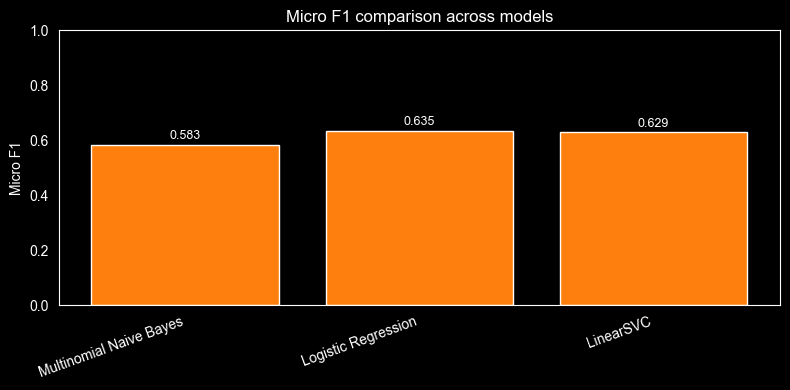

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

lr_d = pd.read_csv("../data/results/logistic_regression_results_dict.csv")
svc_d = pd.read_csv("../data/results/linear_svc_results_dict.csv")
mnb_d = pd.read_csv("../data/results/mnb_results_dict.csv")
df = pd.concat([mnb_d, lr_d, svc_d], ignore_index=True)
micro = df[["model", "micro_f1"]].copy()

plt.figure(figsize=(8,4))
bars = plt.bar(micro["model"], micro["micro_f1"], color="tab:orange")
plt.ylim(0, 1)
plt.ylabel("Micro F1")
plt.title("Micro F1 comparison across models")
plt.xticks(rotation=20, ha="right")
plt.grid(False)
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2,h + 0.01,f"{h:.3f}",ha="center",va="bottom",fontsize=9)

plt.tight_layout()
plt.show()

Overall, dictionary features provide a slight improvement because they add interpretable, label-specific keyword signal, but the effect is limited since TF-IDF managed to already capture most of the same lexical information.

## Model comparison after removing non-label samples

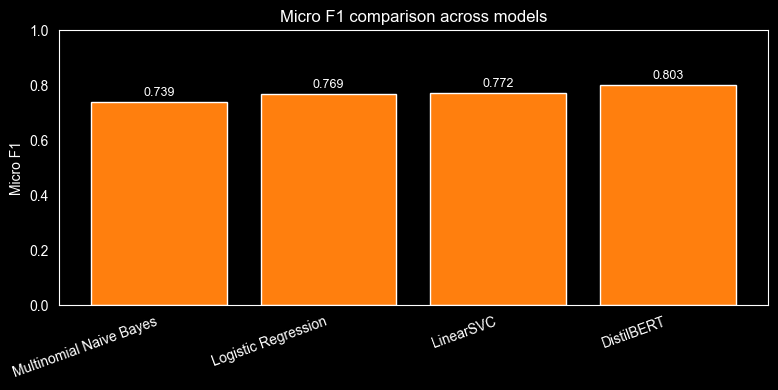

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

lr_d = pd.read_csv("../data/results/logistic_regression_results_dict_new.csv")
svc_d = pd.read_csv("../data/results/linear_svc_results_dict_new.csv")
mnb_d = pd.read_csv("../data/results/mnb_results_dict_new.csv")
bert_new = pd.read_csv("../data/results/distilBert_results_new.csv")
df = pd.concat([mnb_d, lr_d, svc_d, bert_new], ignore_index=True)
micro = df[["model", "micro_f1"]].copy()

plt.figure(figsize=(8,4))
bars = plt.bar(micro["model"], micro["micro_f1"], color="tab:orange")
plt.ylim(0, 1)
plt.ylabel("Micro F1")
plt.title("Micro F1 comparison across models")
plt.xticks(rotation=20, ha="right")
plt.grid(False)
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2,h + 0.01,f"{h:.3f}",ha="center",va="bottom",fontsize=9)

plt.tight_layout()
plt.show()

After removing the non-label samples, the results above show a better overall performance across all main models - all models show improved micro f1 score. DistilBERT benefits most from this due to its ability to use context, while logistic regression and linear SVC remain competitive.